# Deep Q-Network (DQN) From Scratch

This is based on the example from the [pytorch - Reinforcement Learning (DQN) Tutorial](https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html)


In [224]:
%pip install -q torch torchvision matplotlib tensorboard

Note: you may need to restart the kernel to use updated packages.


In [225]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py", 
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/common/")

In [226]:
import gymnasium as gym
import math
import random
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "xpu" if torch.xpu.is_available() else
    "cpu"
)
print(f"Using device: {device}")

import matplotlib
import matplotlib.pyplot as plt
# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

Using device: cpu


In [227]:
# create a folder to store the models in
import os

os.makedirs("models", exist_ok=True)

In [228]:
#env = gym.make("CartPole-v1")
env = gym.make("LunarLander-v3")

## Replay Buffer

A cyclic buffer of bounded size that holds the transitions observed recently. The NN trains on mini-batches sampled from the buffer.

In [229]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [230]:
memory = ReplayMemory(10_000)

**Note:** How does the replay buffer size affect the learning process? 

* If it's too small, we might not have enough diversity in our samples, which can lead to overfitting. 
* If it's too large, we might be using very old experiences that are no longer relevant to the current policy, which can slow down learning. 
* A common choice is to use a replay buffer size of 10,000 to 100,000 transitions.

## Q-Network

A simple feedforward neural network with 2 hidden layers. The final layer is linear since it is a regression task.

In [231]:
# Hidden layer size
HIDDEN_LAYER_SIZE = 128

class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, HIDDEN_LAYER_SIZE)
        self.layer2 = nn.Linear(HIDDEN_LAYER_SIZE, HIDDEN_LAYER_SIZE)
        self.layer3 = nn.Linear(HIDDEN_LAYER_SIZE , n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

Initialize the two used Q-networks. The target net follows the policy net slowly to reduce instability. 

In [232]:
n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations, n_actions).to(device)

# make a copy of the policy network for the target
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict()) 

<All keys matched successfully>

**Notes:** 

* The network performs a regression task (predicts a number). The final activation function is linear (no extra function in code)!
* The Q-Network needs to be powerful enough to learn the relationship between the state representation and the Q-value. 
* A network with a single hidden layer is a universal approximator, but deeper networks often learn faster.  

## Behavior Policy

$\epsilon$-greedy action selection using the Q-network (called here policy net).

In [233]:
#steps_done = 0

# epsilon-greedy action selection
def select_action(state):
    #global steps_done
    #sample = random.random()
    #eps_threshold = EPS_END + (EPS_START - EPS_END) * \
    #    math.exp(-1. * steps_done / EPS_DECAY)
    #steps_done += 1
    #if sample > eps_threshold:
    if random.random() > EPS:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)



## Training

These are just plot functions to visualize the training progress.

In [234]:
def plot_measure(x, label = "", progress=False):
    plt.figure(1)
    x = torch.tensor(x, dtype=torch.float)
    if progress:
        plt.clf()
        plt.title('Training...')
    else:
        plt.title('')

    plt.xlabel('Episode')
    plt.ylabel(label)
    
    plt.plot(x.numpy())
    if len(x) >= 10:
        means = x.unfold(0, 10, 1).mean(1).view(-1)
        #means = torch.cat((torch.zeros(9), means))
        means = torch.cat((torch.full((9,), float('nan')), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    
    if is_ipython:
        if progress:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())


The following function performs the policy network update. It is called by the main training loop below.



Hyperparameters

* BATCH_SIZE is the number of transitions sampled from the replay buffer
* GAMMA is the discount factor as mentioned in the previous section
* EPS_START is the starting value of epsilon
* EPS_END is the final value of epsilon
* EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay
* TAU is the update rate of the target network
* LR is the learning rate of the ``AdamW`` optimizer

In [235]:
BATCH_SIZE = 128
GAMMA = 0.99
#EPS_START = 0.9
#EPS_END = 0.01
#EPS_DECAY = 2500
EPS = 0.1
TAU = 0.005
LR = 0.0001

In [236]:
import numpy as np

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)

episode_durations = []
ep_losses = []
ep_returns = []

# take a batch from the replay buffer and optimize the model. We can do this because Q-learning learns off-policy!
def optimize_model():
    # wait till we have enough samples in the replay memory
    if len(memory) < BATCH_SIZE:
        return np.nan

    # 1. Sample a batch of transitions as (s,a,s',r) tuples from the replay memory. 
    #    Note: All operations are vectorized (they are performed on all tuples)
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # 2. Estimate Q(s_t, a) for the batch of states and actions from the policy_net
    q_values = policy_net(state_batch).gather(1, action_batch)

    # Calculate the update target R + gamma * max_a Q(s_{t+1}, a) using the target_net
    # Edge-case: Exclude final states since there are n next states
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
                
    max_q = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        max_q[non_final_mask] = target_net(non_final_next_states).max(1).values
    
    target_q_values =  reward_batch + (GAMMA * max_q)

    # 3. Compute loss (Huber loss is like L2 for small errors, but avoids exploding gradients by using L1 for large errors)
    criterion = nn.SmoothL1Loss()
    loss = criterion(q_values, target_q_values.unsqueeze(1))

    # 4. Calculate the gradients
    optimizer.zero_grad()
    loss.backward()
    
    # In-place gradient clipping to avoid exploding gradients
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    
    # 5. Update the weights
    optimizer.step()
    return loss.item()

Main training loop.

In [237]:
from matplotlib.pyplot import bar
from tqdm import tqdm

# note: plot_progress is very slow
def train(num_episodes, plot_progress = False, save_policy_every=100):

    if plot_progress:
        plt.ion()

    #env = gym.make("CartPole-v1")
    env = gym.make("LunarLander-v3")

    loop = tqdm(range(num_episodes), desc="Training", disable=plot_progress)
    for i_episode in loop:
        Return = 0.0
        loss = 0.0
        
        # Initialize the environment and get its state
        state, info = env.reset()
        state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        
        for t in count():
            # select next behavioral action (epsilon soft version of the policy net)
            action = select_action(state)
            
            # do action
            observation, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            # update discounted return for this episode and push reward to torch
            Return += reward * GAMMA**t 
            reward = torch.tensor([reward], device=device)
            
            if terminated:
                next_state = None
            else:
                next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

            # Store the transition in memory
            memory.push(state, action, next_state, reward)

            # Move to the next state
            state = next_state

            # Perform one step of the optimization (on the policy network)
            loss += optimize_model()

            # The target network is often updated after a fixed number of steps.
            # Here we use a soft update of the target network's weights instead.
            # θ′ ← τ θ + (1 −τ )θ′
            target_net_state_dict = target_net.state_dict()
            policy_net_state_dict = policy_net.state_dict()
            for key in policy_net_state_dict:
                target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
            target_net.load_state_dict(target_net_state_dict)

            # end of episode: calculate progress statistics and save the policy network
            if done:
                episode_durations.append(t + 1)
                ep_losses.append(loss/t)
                ep_returns.append(Return)
                
                loop.set_postfix({
                    "Return": f"{Return:.2f}",
                    "Loss": f"{loss/t:.4f}",
                    "Duration": t + 1
                })
                
                # plotting progress is very slow!
                if plot_progress:
                    plot_measure(ep_returns, label="Return", progress=True)
                
                if i_episode % save_policy_every == 0:
                    torch.save(policy_net.state_dict(), f'models/DQL_{i_episode}.pth')
                
                break

    # plot the final results
    if plot_progress:
        plt.ioff()
        
    plot_measure(ep_losses, label="Loss", progress=False)
    plot_measure(episode_durations, label="Episode Duration", progress=False)
    plot_measure(ep_returns, label="Return", progress=False)
    plt.show()
  

Training: 100%|██████████| 1000/1000 [48:24<00:00,  2.90s/it, Return=82.15, Loss=0.4227, Duration=253]  


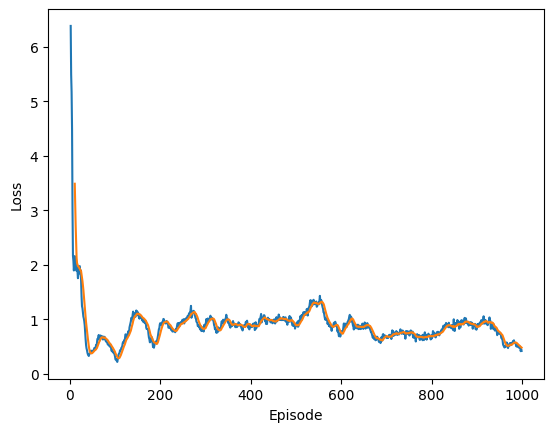

<Figure size 640x480 with 0 Axes>

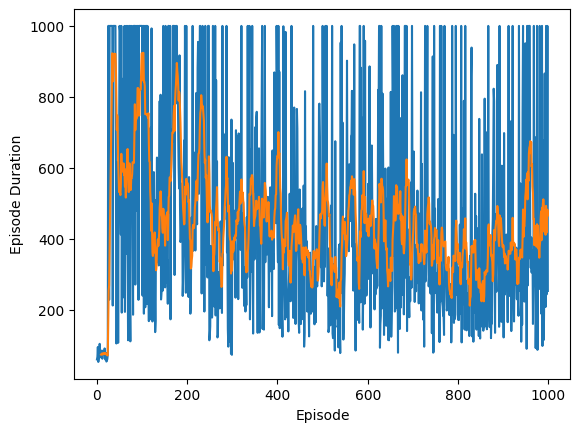

<Figure size 640x480 with 0 Axes>

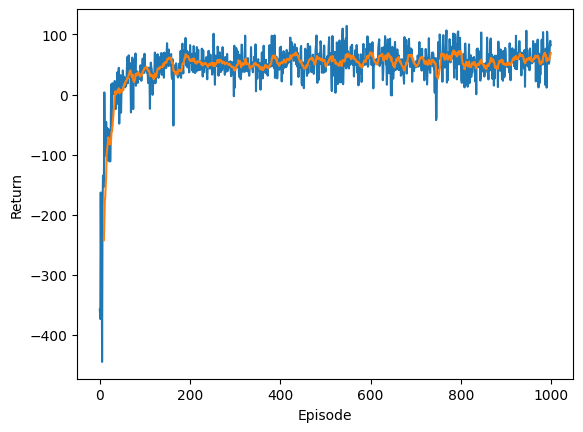

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [238]:
TRAIN = False
TRAIN = True

if TRAIN:
    train(1000, save_policy_every=50, plot_progress=False)

In [241]:
if TRAIN:
    torch.save(policy_net.state_dict(), 'models/DQL_final.pth')

**Note:** Deep Q-Learning (DQN), it is completely normal for the learning loss to fluctuate (go up and down) or even increase while performance improves. Unlike supervised learning where a fixed dataset leads to a steady decline in loss, DQN loss behaves differently for several technical reasons:

* Moving Target: As the agent learns, these target values constantly change (the "moving target" problem).
* Changing Data Distribution: 
  - New Discoveries: agent discovers a high-reward state it hasn't seen before, 
  - Buffer Turnover: As old "easy" experiences are replaced by new "complex" ones
*  Target Network Syncing: Note we use here "soft" syncing, so no spike.

**Note:** Learning improves when the reward structure provide early feedback about desired behavior.

For example, for the Lunar Lander the reward includes for each step:

* is increased/decreased the closer/further the lander is to the landing pad.
* is increased/decreased the slower/faster the lander is moving.
* is decreased the more the lander is tilted (angle not horizontal).
* is increased by 10 points for each leg that is in contact with the ground.
* is decreased by 0.03 points each frame a side engine is firing.
* is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

## Compare the Model During Learning

I load the models that were saved during training an run a single episode using the learned policy network. This shows the evolution of the policy over the learning process. The first policy network is the random initialization.

In [245]:
env_orig = gym.make('LunarLander-v3', render_mode="rgb_array")
env = VideoWrapper(env_orig, 'DQN_from_scratch', render_fps=30)

models = list(range(0,950,50)) + ["final"]
for m in models:
    model = DQN(n_observations, n_actions).to(device)
    model.load_state_dict(torch.load(f'models/DQL_{m}.pth', weights_only=True))
    model.eval() # Set to evaluation mode for inference   
    policy_net = model

    attempts = 1
    for _ in range(attempts):
        state, info = env.reset()
        for t in count():
            action = policy_net(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)).max(1).indices.view(1, 1)
            observation, reward, terminated, truncated, _ = env.step(action.item())
            state = observation
            if terminated or truncated:
                break
    
env.close()


Videos already exist, I remove them first!


/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/mhahsler/github/Introduction_to_Reinforcement_Learning/DRL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [246]:
for i in range(len(models)):
    print(f"DQN after {models[i]} episodes of training") 
    show(env, i)

DQN after 0 episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-0.mp4


DQN after 50 episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-1.mp4


DQN after 100 episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-2.mp4


DQN after 150 episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-3.mp4


DQN after 200 episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-4.mp4


...

DQN after 750 episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-15.mp4


DQN after 800 episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-16.mp4


DQN after 850 episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-17.mp4


DQN after 900 episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-18.mp4


DQN after final episodes of training
Showing: ./videos/video_DQN_from_scratch-episode-19.mp4


## Run the Final Trained Model

In [247]:
model = DQN(n_observations, n_actions).to(device)
model.load_state_dict(torch.load('models/DQL_final.pth', weights_only=True))
model.eval() # Set to evaluation mode for inference

policy_net = model


In [248]:
from gymnasium_display_recorder import VideoWrapper, show

#env_orig = gym.make("CartPole-v1", render_mode="rgb_array")
env_orig = gym.make('LunarLander-v3', render_mode="rgb_array")
env = VideoWrapper(env_orig, 'DQN_from_scratch_final', render_fps=30)

attempts = 5
for _ in range(attempts):
    state, info = env.reset()
    for t in count():
        action = policy_net(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)).max(1).indices.view(1, 1)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        state = observation
        if terminated or truncated:
            break
        
env.close()

In [249]:
for i in range(attempts):
    show(env, i)


Showing: ./videos/video_DQN_from_scratch_final-episode-0.mp4


Showing: ./videos/video_DQN_from_scratch_final-episode-1.mp4


Showing: ./videos/video_DQN_from_scratch_final-episode-2.mp4


Showing: ./videos/video_DQN_from_scratch_final-episode-3.mp4


Showing: ./videos/video_DQN_from_scratch_final-episode-4.mp4
